In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

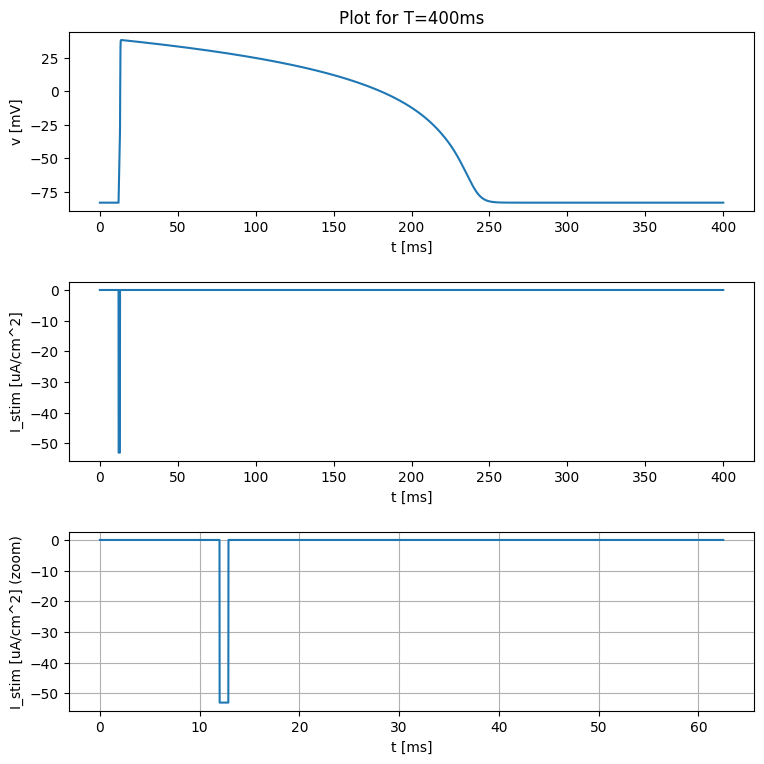

output_data shape: (300, 80001, 1), t shape: (80001,), a_stim shape: (300, 1), d_stim shape: (300, 1), t_stim shape: (300, 1)


In [4]:
def plotting_impluse_action_potential(t, v, I_stim, T):
    fig, ax = plt.subplots(3,1, figsize=(8, 8))
    ax[0].plot(t, v)
    ax[0].set_xlabel("t [ms]")
    ax[0].set_ylabel("v [mV]")
    ax[0].title.set_text(f"Plot for T={T}ms")
    ax[1].plot(t, I_stim)
    ax[1].set_xlabel("t [ms]")
    ax[1].set_ylabel("I_stim [uA/cm^2]")
    ax[2].plot(t[:12500], I_stim[:12500])
    ax[2].set_xlabel("t [ms]")
    ax[2].set_ylabel("I_stim [uA/cm^2] (zoom)")
    plt.grid()
    fig.tight_layout(pad=2.0)
    plt.show()

def I_stim(t, a_stim, d_stim, t_stim):
    return sum(
        a_stim_ * (t >= t_stim_) * (t <= t_stim_ + d_stim_) 
        for t_stim_, d_stim_, a_stim_ in zip(t_stim, d_stim, a_stim)
    )

T, dt = 400, 0.005                 # in ms
N = 300                            # number of samples
df = np.load(f"pr_n_data_{N}_T_400_dt_0.005_d_stim_0.88.npz")

output_data = df['v']
t_stim = df['t_stim']
a_stim = df['a_stim']
d_stim = df['d_stim']
t = np.arange(0, T+dt, dt)

train_idx = df['train_idx']
val_idx = df['val_idx']
test_idx = df['test_idx']

plotting_impluse_action_potential(t, output_data[0], I_stim(t, a_stim[0], d_stim[0], t_stim), T=T)
print(f"output_data shape: {output_data.shape}, t shape: {t.shape}, a_stim shape: {a_stim.shape}, d_stim shape: {d_stim.shape}, t_stim shape: {t_stim.shape}")

(300, 3)


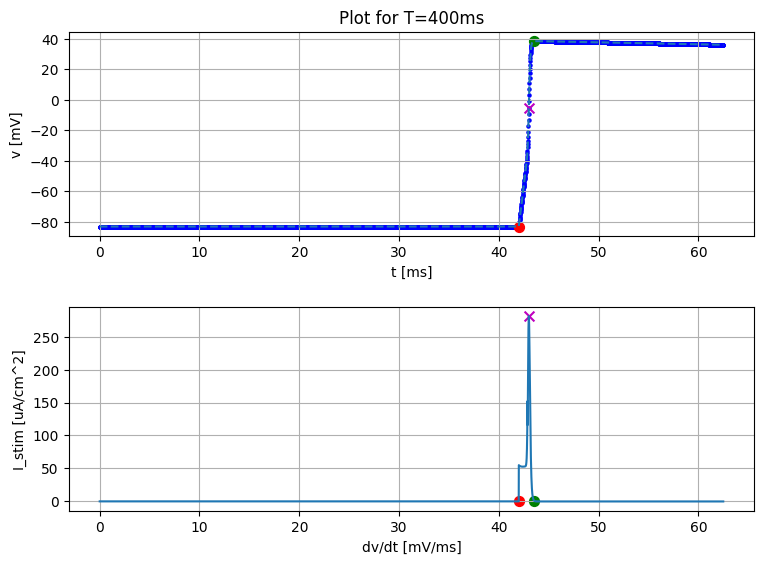

In [5]:
def find_jump_from_derivative(dv_dt, threshold_frac=0.10, num_peak=1):
    abs_dv_dt = np.abs(dv_dt)
    peak_idx = np.argpartition(abs_dv_dt, -num_peak)[-num_peak:][0]

    # check left and right, until back to smooth region (derivative below threshold) 
    threshold = threshold_frac * abs_dv_dt[peak_idx]

    start_idx = next((i for i in range(peak_idx, -1, -1) if abs_dv_dt[i] <= threshold), 0)
    end_idx = next((i for i in range(peak_idx, len(dv_dt)) if abs_dv_dt[i] < threshold), len(dv_dt)-1)
    
    return start_idx, end_idx, peak_idx

def plotting_impluse_action_potential(t, v, dv_dt, jump_idx):
    fig, ax = plt.subplots(2,1, figsize=(8, 6))
    ax[0].plot(t[:12500], v[:12500], linestyle='--')
    ax[0].scatter(t[:12500:3], v[:12500:3], color='b', label='Sample points', s=5)
    ax[0].scatter(t[jump_idx[0]], v[jump_idx[0]], color='r', label='Jump Start', s=50, marker='o')
    ax[0].scatter(t[jump_idx[1]], v[jump_idx[1]], color='g', label='Jump End', s=50, marker='o')
    ax[0].scatter(t[jump_idx[2]], v[jump_idx[2]], color='m', label='Jump Peak', s=50, marker='x')
    ax[0].set_xlabel("t [ms]")
    ax[0].set_ylabel("v [mV]")
    ax[0].grid()
    ax[0].title.set_text(f"Plot for T={T}ms")

    ax[1].plot(t[:12500], dv_dt[:12500])
    ax[1].scatter(t[jump_idx[0]], dv_dt[jump_idx[0]], color='r', label='Jump Start', s=50, marker='o')
    ax[1].scatter(t[jump_idx[1]], dv_dt[jump_idx[1]], color='g', label='Jump End', s=50, marker='o')
    ax[1].scatter(t[jump_idx[2]], dv_dt[jump_idx[2]], color='m', label='Jump Peak', s=50, marker='x')
    ax[1].set_xlabel("dv/dt [mV/ms]")
    ax[1].set_ylabel("I_stim [uA/cm^2]")

    plt.grid()
    fig.tight_layout(pad=2.0)
    plt.show()

sharp_jump_all = []
for v in output_data:
    dv_dt = np.gradient(v.flatten(), t)
    start, end, peak = find_jump_from_derivative(dv_dt, threshold_frac=0.005)
    sharp_jump_all.append(np.array([start, end, peak]))

print(np.array(sharp_jump_all).shape)
sample_id = 5
plotting_impluse_action_potential(t, output_data[sample_id], np.gradient(output_data[sample_id].flatten(), t), sharp_jump_all[sample_id])

In [18]:
np.savez(
    f"pr_n_data_{N}_one_sharp.npz",
    sharp_jump=np.array(sharp_jump_all),       # (N, 3) start_idx, end_idx, peak_idx
    t_stim=t_stim,                             # (N,)
    a_stim=a_stim,                             # (N,)
    d_stim=d_stim,                             # (N,)
    t=t                                        # (Nt,)
)